In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cvxpy as cp

from safety_formation.formation import Agent,Topology
from safety_formation.control_law.nominal import CentralizedFormationControl
from safety_formation.control_law.cbf import CentralizedCBF

## Topology

<Axes: title={'center': 'Topology (Leader=0, Followers=1..N)'}>

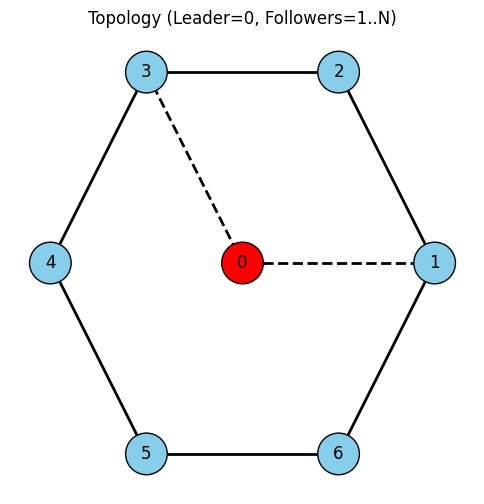

In [2]:
adj_matrix = np.array([
    [0, 1, 0, 0, 0, 1],
    [1, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0, 0],
    [0, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 0],
], dtype=float)

leader_access = [1, 0, 1, 0, 0, 0]

topo = Topology(num_agents=6, adjacency_matrix=adj_matrix, leader_access=leader_access)

topo.plot()

## Agent creation

In [3]:
# Define formation offsets (f_i) for each follower
f1 = [1, 0, 0, 0]
f2 = [1/2, np.sqrt(3)/2, 0, 0]
f3 = [-1/2, np.sqrt(3)/2, 0, 0]
f4 = [-1, 0, 0, 0]
f5 = [-1/2, -np.sqrt(3)/2, 0, 0]
f6 = [1/2, -np.sqrt(3)/2, 0, 0]

f_list = [f1, f2, f3, f4, f5, f6]

# print(np.array(f_list)[:,:2])
# print("\n")

# Agent creation (N = 6)
N = 6

# Initial states (x0) for each agent: [x, y, vx, vy]
x0_0 = [0, 0, 0.5, 0]
x1_0 = [-2, 0, -0.5, 0]
x2_0 = [0, 2, 0.2, -0.2]
x3_0 = [0, 1, 1, 0]
x4_0 = [2, 2, 0, 0]
x5_0 = [0, -2, 0, 1]
x6_0 = [2, -2, 0.3, 0]

xi_0_list = [x0_0, x1_0, x2_0, x3_0, x4_0, x5_0, x6_0]

leader = Agent(agent_id=0, x0=x0_0, f_target=[0, 0, 0, 0])  # Leader has no formation offset
agents = []
for i in range(N):
    agents.append(Agent(agent_id=i+1, x0=xi_0_list[i+1], f_target=f_list[i], alpha = 12))

# for agent in agents:
#     print(f"Agent {agent.id} Initial state: \n {agent.state}, \n Formation offset: \n {agent.f} \n")

## Gain Calculation

In [4]:
K = np.array([
        [1.6978, -0.0004, 3.9308, 0.0005],
        [0.0002, 1.6966, 0.0005, 3.9309],
    ], dtype=float)
K_prime = np.zeros_like(K)  # No leader feedforward in this example

## Simulation

In [5]:
from utils import ErrorTracker, compute_delta_norms
from utils import plot_formation_error, plot_relative_trajectories, plot_world_trajectories, generate_formation_video


controller = CentralizedFormationControl(K_matrix=K, K_prime_matrix=K_prime)
safety_filter = CentralizedCBF(gamma= 0.2, safety_dis= 0.5 )
tracker = ErrorTracker()

dt = 0.1
T = 10.0
steps = int(T / dt)

for k in range(steps):

     # ---- Controller (centralized) ----
    U = controller.compute_nominal(
        all_agents=agents,
        topology=topo,
        leader_state=leader.state
    )  # shape (N,2)
    
    U_safe = safety_filter.compute_safe_control(
        all_agents=agents, 
        topology=topo, 
        u_nom= U
    )
    
    # ---- Apply control to each follower ----
    for i, ag in enumerate(agents):
        ag.update_physics(U_safe[i], dt)

    # ---- Leader dynamics (optional) ----
    # Ví dụ leader constant velocity:
    leader.update_physics([0, 0], dt)

    # ---- Track error ----
    tracker.step(agents, leader.state)

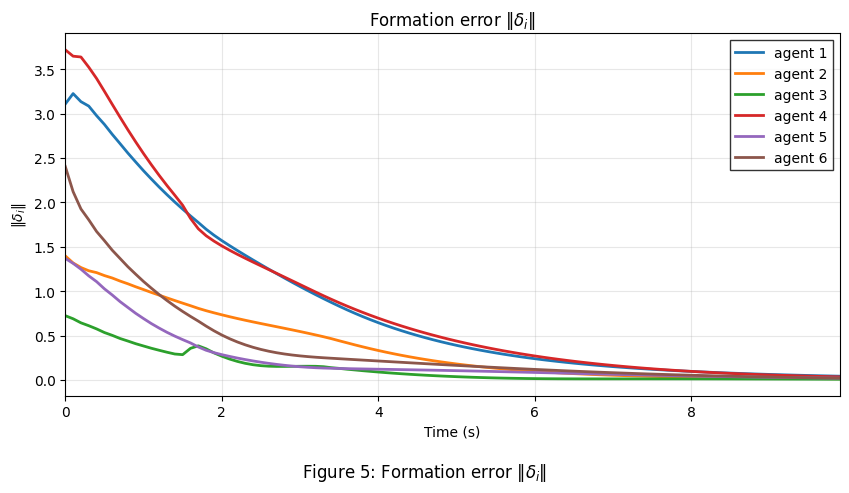

In [6]:
norms = compute_delta_norms(agents, leader, use_pos_only=False)  # dùng 4D error
# hoặc use_pos_only=True nếu paper chỉ xét position error

plot_formation_error(
    norms,
    dt=dt,
    caption=r"Figure 5: Formation error $\|\delta_i\|$"
)

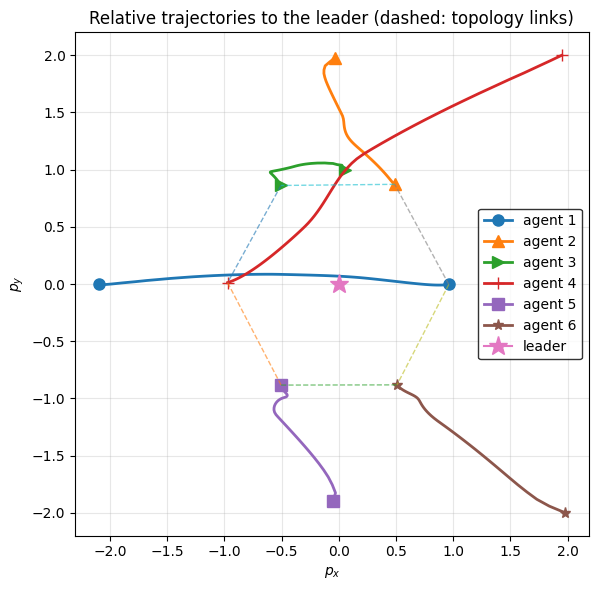

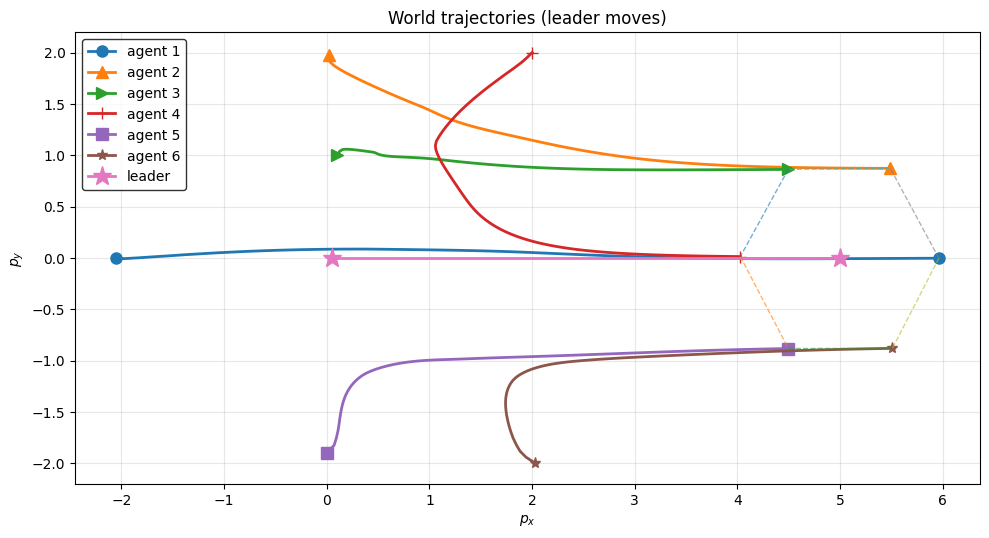

In [7]:
plot_relative_trajectories(agents, leader, topo, show_topology_at="final")
plot_world_trajectories(agents, leader, topo, topology_at="final")

for ag in agents:
    ag.clear_history

In [8]:
generate_formation_video(agents, leader, dt, filename= "centralized_cbf_formation_control.mp4", graph_title= "Formation Control with Centralized CBF")

Generating centralized_cbf_formation_control.mp4...
Video generation complete.
